# Analysis of NBA ESPN Fantasy League

Author: Ashkaan Gaurav Singh

## Questions looking to be answered

What players are the best value for their earnings?

What players create the largest fantasy points per game? (i.e. what fantasy team is the highest performing squad)

In 2020 ESPN introduced a new Fantasy Points scoring system. According to ESPN, this new system better reflected the Modern NBA. The scoring system is as follows:

- Point = 1

- 3PM = 1 (3 Point Make)

- FGA = -1 (Field Goal Attemp)

- FGM = 2 (Field Goal Make)

- FTA = -1 (Free Throw Attempt)

- FTM = 1 (Free Throw Make)

- REB = 1 (Rebound)

- AST = 2 (Assist)

- STL = 4 (Steal)

- BLK = 4 (Block)

- TOV = -2 (Turnover)

## Data

The data is a Kaggle Dataset which can be found here: https://www.kaggle.com/datasets/ratin21/nba-player-stats-and-salaries-2000-2025

Initial Data had issues with incorrect Player Names. I manually made the changes and remade the datatset done below. Initial data found on the github page: https://github.com/edwinjeon/NBA-Salary-Prediction

In [2]:
import pandas as pd
file_name = 'my_data.csv'

data = pd.read_csv(file_name)
data.head()

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Shaquille O'Neal,17142000,2000,C,27.0,LAL,79.0,79.0,40.0,12.1,...,0.524,4.3,9.4,13.6,3.8,0.5,3.0,2.8,3.2,29.7
1,Kevin Garnett,16806000,2000,PF,23.0,MIN,81.0,81.0,40.0,9.4,...,0.765,2.8,9.0,11.8,5.0,1.5,1.6,3.3,2.5,22.9
2,Alonzo Mourning,15004000,2000,C,29.0,MIA,79.0,78.0,34.8,8.3,...,0.711,2.7,6.8,9.5,1.6,0.5,3.7,2.7,3.9,21.7
3,Juwan Howard,15000000,2000,PF,26.0,WAS,82.0,82.0,35.5,6.2,...,0.735,1.6,4.1,5.7,3.0,0.8,0.3,2.7,3.6,14.9
4,Scottie Pippen,14795000,2000,SF,34.0,POR,82.0,82.0,33.5,4.7,...,0.717,1.4,4.9,6.3,5.0,1.4,0.5,2.5,2.5,12.5


In [3]:
data_current = data

Some players are listed with multiple positions (e.g., SG-PG, PF-C). For simplicity, the first listed position is taken as the player's primary position. Multi-position players account for only a small proportion of the dataset (approximately 2%), so this simplification is unlikely to materially affect positional summary statistics.

In [4]:
data_current['Pos'].value_counts()

Pos
SG       2144
PG       1898
SF       1830
PF       1795
C        1400
SF-SG      28
PG-SG      28
SG-PG      23
SG-SF      21
PF-SF      19
C-PF       18
PF-C       17
SF-PF      17
SG-PF       4
PG-SF       1
SF-C        1
Name: count, dtype: int64

In [5]:
data_current['Pos'] = data_current['Pos'].str.split('-').str[0]
data_current['Pos'].value_counts()

Pos
SG    2192
PG    1927
SF    1876
PF    1831
C     1418
Name: count, dtype: int64

Next we will map the data's headers to the Fantasy Points structure for consistency.

In [6]:
print(data_current.columns)

Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS'],
      dtype='object')


In [7]:
new_columns = {'PTS': 'Points', '3P': '3PM', 'FGA': 'FGA', 'FG': 'FGM', 'FTA': 'FTA', 'FT': 'FTM', 'TRB': 'REB', 'AST': 'AST', 'STL': 'STL', 'BLK': 'BLK', 'TOV': 'TOV'}

data_current = data_current.rename(columns=new_columns)
print(data_current.columns)

Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP',
       'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FTM', 'FTA', 'FT%', 'ORB', 'DRB', 'REB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'Points'],
      dtype='object')


Now we calculate all of the players fantasy points and add it as a column in the dataframe.

In [8]:
# FPPG = Fantasy Points Per Game
data_current['FPPG'] = ( data_current['Points'] 
                                  + data_current['3PM'] - data_current['FGA'] + (data_current['FGM'] * 2) - data_current['FTA'] 
                                  + data_current['FTM'] + data_current['REB'] + (data_current['AST'] * 2) + (data_current['STL'] * 4)
                                  + (data_current['BLK'] * 4) - (data_current['TOV'] * 2) 
)

# FPPGS = Fantasy Points Per Game Starter

# TFP = Total Fantasy Points
data_current['TFP'] = data_current['G'] * data_current['FPPG']

# FPPM = Fantasy Points Per Minute
data_current['FPPM'] = round(data_current['TFP'] / (data_current['MP'] * data_current['G']), 2)

# FPPD = Fantasy Points Per Dollar
data_current['FPPD'] = data_current['TFP'] / (data_current['Salary'] * data_current['G']) / 82

DATA = data_current
DATA.head()

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FGM,...,AST,STL,BLK,TOV,PF,Points,FPPG,TFP,FPPM,FPPD
0,Shaquille O'Neal,17142000,2000,C,27.0,LAL,79.0,79.0,40.0,12.1,...,3.8,0.5,3.0,2.8,3.2,29.7,57.5,4542.5,1.44,4.090652e-08
1,Kevin Garnett,16806000,2000,PF,23.0,MIN,81.0,81.0,40.0,9.4,...,5.0,1.5,1.6,3.3,2.5,22.9,49.7,4025.7,1.24,3.606436e-08
2,Alonzo Mourning,15004000,2000,C,29.0,MIA,79.0,78.0,34.8,8.3,...,1.6,0.5,3.7,2.7,3.9,21.7,45.2,3570.8,1.30,3.673817e-08
3,Juwan Howard,15000000,2000,PF,26.0,WAS,82.0,82.0,35.5,6.2,...,3.0,0.8,0.3,2.7,3.6,14.9,23.6,1935.2,0.66,1.918699e-08
4,Scottie Pippen,14795000,2000,SF,34.0,POR,82.0,82.0,33.5,4.7,...,5.0,1.4,0.5,2.5,2.5,12.5,30.6,2509.2,0.91,2.522276e-08


### Players Fantasy Points Per Game vs Earnings for the 2025 Season

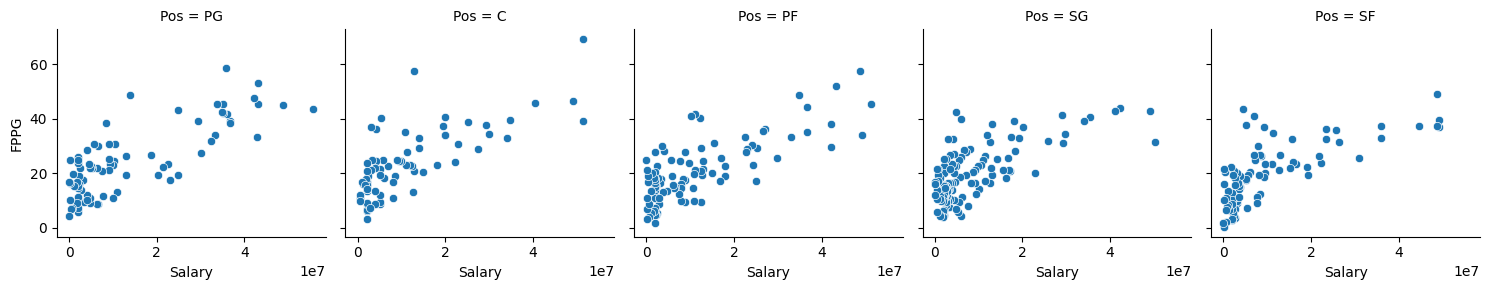

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(DATA[(DATA['Year'] == 2025) & (DATA['G'] >= 0)], col="Pos") # Wraps to 2 columns
g.map(sns.scatterplot, 'Salary', 'FPPG')
plt.show()

## Distributions of Fantasy Points by Position

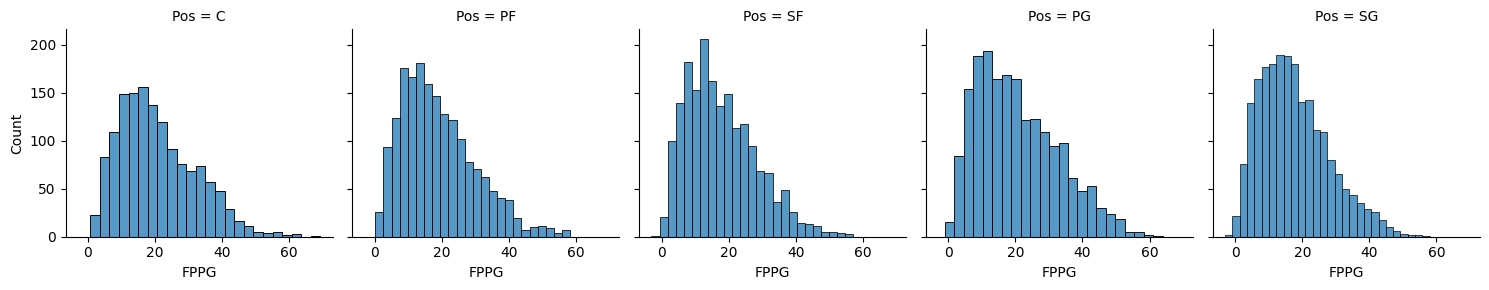

In [10]:
POS = ['PG', 'SG', 'SF', 'PF', 'C']
g = sns.FacetGrid(DATA[DATA['Pos'].isin(['PG', 'SG', 'SF', 'PF', 'C'])], col="Pos") # Wraps to 2 columns
g.map(sns.histplot, "FPPG")
plt.show()

In [11]:
stats = DATA.groupby("Pos")["FPPG"].agg(["mean", "std"])

stats['dispersion'] = (stats['std'] ** 2) / stats['mean']
print(stats)

          mean        std  dispersion
Pos                                  
C    20.728773  11.378526    6.245948
PF   18.976952  11.040961    6.423730
PG   20.696783  12.121602    7.099327
SF   17.719829  10.480307    6.198527
SG   17.626232  10.308928    6.029309


## Best Fantasy Team In Each Season

We will assume a team size of 10 players.

### Function to Get Best Fantasy Team Each Season

This function simply takes the Highest totalling players in terms of fantasy points by position initially so that a "starting 5" can be produced. Then the next 5 are simply the next 5 highest scoring fantasy players.

In [12]:
def get_best_team(DATA, YEAR, TEAM_SIZE = 10):
    DATA_YEAR = DATA[DATA['Year'] == YEAR].sort_values(by='TFP', ascending=False).reset_index()

    TEAM = []

    POS = ['PG', 'SG', 'SF', 'PF', 'C']

    for pos in POS:
        DATA_SORTED = DATA_YEAR[DATA_YEAR['Pos'] == pos]
        INDEX = DATA_SORTED.index[0]
        DATA_POINT = DATA_SORTED.loc[INDEX]
        
        TEAM.append({'Name': DATA_POINT['Player'], 
                     'Games': DATA_POINT['G'],
                     'FPPG': round(DATA_POINT['FPPG'], 2), 
                     'TFP': round(DATA_POINT['TFP'], 2), 
                     'Salary': DATA_POINT['Salary'], 
                     'Position': pos, 
                     'Role': 'STARTER'})
        DATA_YEAR = DATA_YEAR.drop(INDEX, axis=0)

    for _, row in DATA_YEAR.head(TEAM_SIZE - 5).iterrows():
        TEAM.append({'Name': row['Player'], 
                     'Games': row['G'],
                     'FPPG': round(row['FPPG'], 2), 
                     'TFP': round(row['TFP'], 2), 
                     'Salary': row['Salary'], 
                     'Position': pos, 
                     'Role': 'BENCH'})
    return TEAM

# Get Best Teams

YEARS = DATA['Year'].unique()

BEST_TEAMS = {}

for year in YEARS:
    BEST_TEAMS[year] = get_best_team(DATA, year)

### Quick Statistics

In [104]:
def fantasy_team_stats(TEAM):

    TOTAL_F_POINTS = 0
    TOTAL_SALARY = 0
    TOTAL_F_POINTS_PER_GAME = 0
    AVERAGE_GAMES_PLAYED = 0

    for player in TEAM:
        TOTAL_F_POINTS += int(player['TFP'])
        TOTAL_SALARY += int(player['Salary'])
        TOTAL_F_POINTS_PER_GAME += int(player['FPPG'])
        AVERAGE_GAMES_PLAYED += int(player['Games'])

    return {
        "Total Fantasy Points": TOTAL_F_POINTS,
        "Total Fantasy Points Per Game": TOTAL_F_POINTS_PER_GAME,
        "Total Salary": TOTAL_SALARY,
        "Average Games Played": round(AVERAGE_GAMES_PLAYED/len(TEAM), 2)
    }

### 2025

In [14]:
BEST_TEAMS[2025]

[{'Name': 'Shai Gilgeous-Alexander',
  'Games': 76.0,
  'FPPG': 58.5,
  'TFP': 4446.0,
  'Salary': 35859950,
  'Position': 'PG',
  'Role': 'STARTER'},
 {'Name': 'Anthony Edwards',
  'Games': 79.0,
  'FPPG': 44.0,
  'TFP': 3476.0,
  'Salary': 42176400,
  'Position': 'SG',
  'Role': 'STARTER'},
 {'Name': 'LeBron James',
  'Games': 70.0,
  'FPPG': 49.2,
  'TFP': 3444.0,
  'Salary': 48728845,
  'Position': 'SF',
  'Role': 'STARTER'},
 {'Name': 'Giannis Antetokounmpo',
  'Games': 67.0,
  'FPPG': 57.5,
  'TFP': 3852.5,
  'Salary': 48787676,
  'Position': 'PF',
  'Role': 'STARTER'},
 {'Name': 'Nikola Jokic',
  'Games': 70.0,
  'FPPG': 69.4,
  'TFP': 4858.0,
  'Salary': 51415938,
  'Position': 'C',
  'Role': 'STARTER'},
 {'Name': 'James Harden',
  'Games': 79.0,
  'FPPG': 45.3,
  'TFP': 3578.7,
  'Salary': 33653846,
  'Position': 'C',
  'Role': 'BENCH'},
 {'Name': 'Jayson Tatum',
  'Games': 72.0,
  'FPPG': 48.6,
  'TFP': 3499.2,
  'Salary': 34848340,
  'Position': 'C',
  'Role': 'BENCH'},
 {'N

In [15]:
fantasy_team_stats(BEST_TEAMS[2025])

{'Total Fantasy Points': 37495.3,
 'Total Fantasy Points Per Game': 514.3000000000001,
 'Total Salary': 394620144,
 'Average Games Played': 73.2}

### By Season Comparison

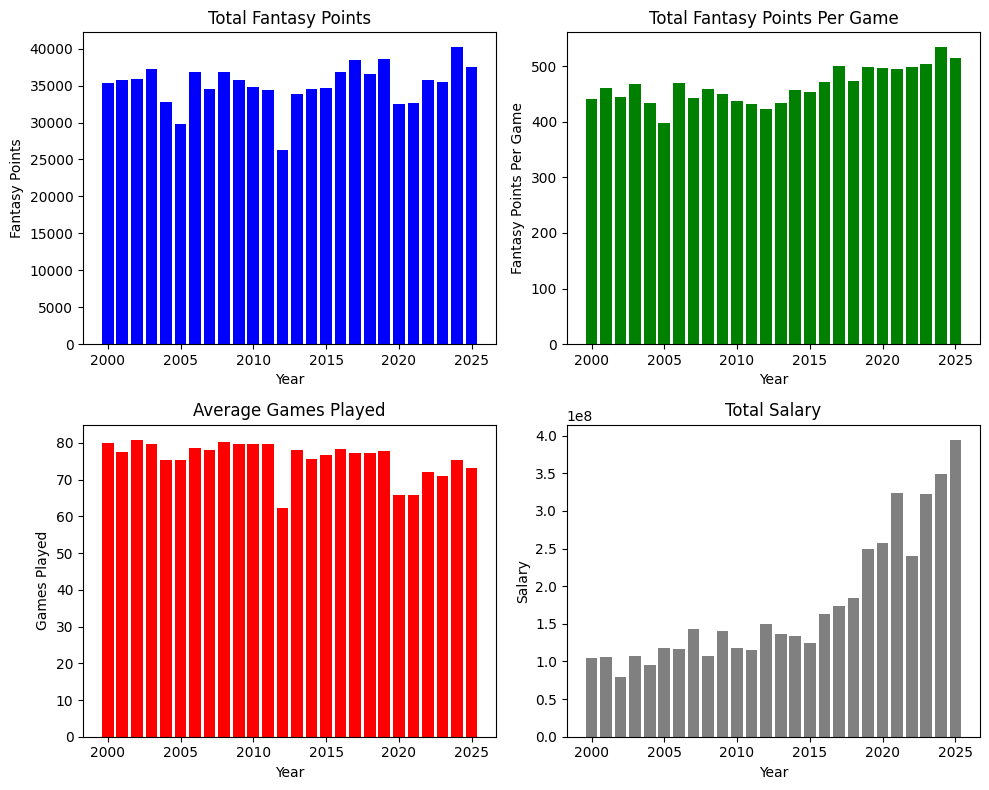

In [16]:
YEARS = DATA['Year'].unique()

FANTASY_TEAM_STATS = {}

for year in YEARS:
    FANTASY_TEAM_STATS[year] = fantasy_team_stats(BEST_TEAMS[year])

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Fantasy Points'] for year in YEARS], color="blue")
axs[0,0].set_title("Total Fantasy Points")
axs[0,0].set_xlabel('Year')
axs[0,0].set_ylabel('Fantasy Points')

axs[0,1].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Fantasy Points Per Game'] for year in YEARS], color="green")
axs[0,1].set_title("Total Fantasy Points Per Game")
axs[0,1].set_xlabel('Year')
axs[0,1].set_ylabel('Fantasy Points Per Game')

axs[1,0].bar(YEARS, [FANTASY_TEAM_STATS[year]['Average Games Played'] for year in YEARS], color="red")
axs[1,0].set_title("Average Games Played")
axs[1,0].set_xlabel('Year')
axs[1,0].set_ylabel('Games Played')

axs[1,1].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Salary'] for year in YEARS], color="grey")
axs[1,1].set_title("Total Salary")
axs[1,1].set_xlabel('Year')
axs[1,1].set_ylabel('Salary')

plt.tight_layout()

plt.show()

## Exploring Whether Teams of Same Positions are Better Against Other Teams With Full of Same Positions

In [17]:
def get_best_team_position(DATA, YEAR, POSITION, TEAM_SIZE = 10):
    DATA_YEAR = DATA[(DATA['Year'] == YEAR) & (DATA['Pos'] == POSITION)].sort_values(by='TFP', ascending=False).reset_index()

    TEAM = []

    for i in range(5):
        DATA_SORTED = DATA_YEAR[DATA_YEAR['Pos'] == POSITION]
        INDEX = DATA_SORTED.index[0]
        DATA_POINT = DATA_SORTED.loc[INDEX]
        
        TEAM.append({'Name': DATA_POINT['Player'], 
                     'Games': DATA_POINT['G'],
                     'FPPG': round(DATA_POINT['FPPG'], 2), 
                     'TFP': round(DATA_POINT['TFP'], 2), 
                     'Salary': DATA_POINT['Salary'], 
                     'Position': POSITION, 
                     'Role': 'STARTER'})
        DATA_YEAR = DATA_YEAR.drop(INDEX, axis=0)

    for idx, row in DATA_YEAR.head(TEAM_SIZE - 5).iterrows():
        TEAM.append({'Name': row['Player'], 
                     'Games': row['G'],
                     'FPPG': round(row['FPPG'], 2), 
                     'TFP': round(row['TFP'], 2), 
                     'Salary': row['Salary'], 
                     'Position': POSITION, 
                     'Role': 'BENCH'})
    return TEAM

YEARS = DATA['Year'].unique()

POS = ['PG', 'SG', 'SF', 'PF', 'C']

BEST_TEAMS_BY_YEAR_POSITIONS = {}

for year in YEARS:
    BEST_TEAMS_BY_YEAR_POSITIONS[year] = {}
    for pos in POS:
        BEST_TEAMS_BY_YEAR_POSITIONS[year][pos] = get_best_team_position(DATA, year, pos)

In [18]:
def run_comparison_positions(TEAMS):
    POS = ['PG', 'SG', 'SF', 'PF', 'C']

    YEARS_BEST = {pos: [] for pos in POS}

    for year in TEAMS.keys():
        BEST_POSITION = ''
        BEST_POSITION_VALUE = 0

        for pos in POS:
            STATS = fantasy_team_stats(TEAMS[year][pos])

            # print(BEST_POSITION, BEST_POSITION_VALUE)

            if STATS['Total Fantasy Points'] > BEST_POSITION_VALUE:
                BEST_POSITION = pos
                BEST_POSITION_VALUE = STATS['Total Fantasy Points']
        
        YEARS_BEST[BEST_POSITION].append(year)
    
    return YEARS_BEST


In [19]:
ANAYLSIS_OUT = run_comparison_positions(BEST_TEAMS_BY_YEAR_POSITIONS)

In [20]:
for pos in ANAYLSIS_OUT.keys():
    for year in ANAYLSIS_OUT[pos]:
        STATS_1 = fantasy_team_stats(BEST_TEAMS[year])
        STATS_2 = fantasy_team_stats(BEST_TEAMS_BY_YEAR_POSITIONS[year][pos])

        print(f"The best position only team in {year} was {pos} with a difference to the Best Team in the year by {round(STATS_1['Total Fantasy Points'] - STATS_2['Total Fantasy Points'], 2)}")

The best position only team in 2000 was PG with a difference to the Best Team in the year by 6459.1
The best position only team in 2007 was PG with a difference to the Best Team in the year by 6227.5
The best position only team in 2008 was PG with a difference to the Best Team in the year by 5961.7
The best position only team in 2009 was PG with a difference to the Best Team in the year by 6776.2
The best position only team in 2010 was PG with a difference to the Best Team in the year by 5967.7
The best position only team in 2011 was PG with a difference to the Best Team in the year by 5037.3
The best position only team in 2012 was PG with a difference to the Best Team in the year by 3873.5
The best position only team in 2013 was PG with a difference to the Best Team in the year by 4357.7
The best position only team in 2015 was PG with a difference to the Best Team in the year by 3486.4
The best position only team in 2016 was PG with a difference to the Best Team in the year by 3411.7


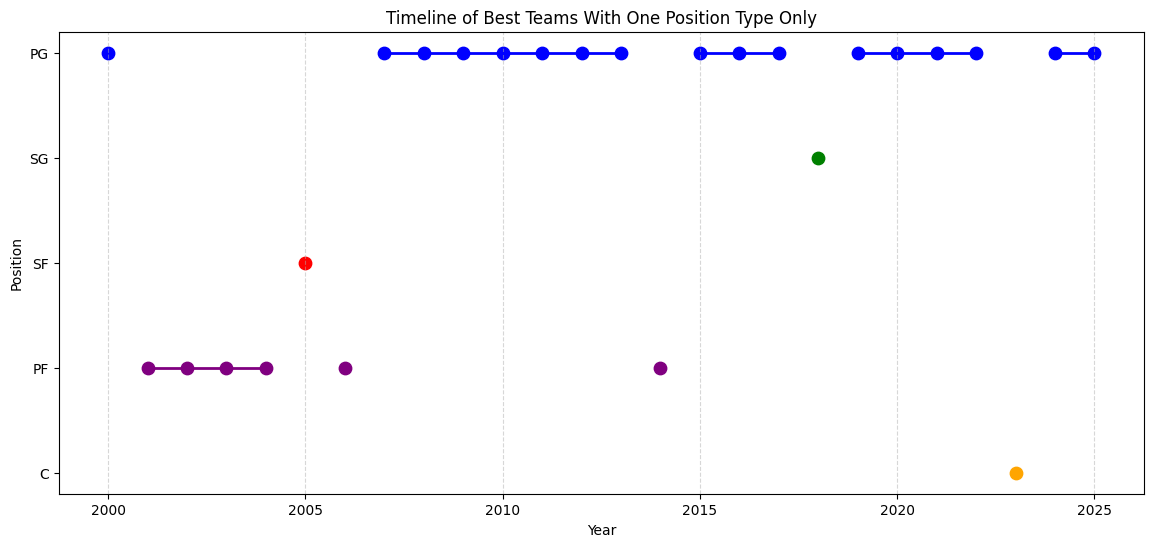

In [21]:
positions = ['PG', 'SG', 'SF', 'PF', 'C'][::-1]
y_map = {pos: i for i, pos in enumerate(positions)}

fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'PG': 'blue',
    'SG': 'green',
    'SF': 'red',
    'PF': 'purple',
    'C': 'orange'
}

for pos, years in ANAYLSIS_OUT.items():
    years = sorted(years)
    y = y_map[pos]

    ax.scatter(years, [y]*len(years), s=80, color=colors[pos])

    for i in range(len(years) - 1):
        if years[i+1] == years[i] + 1:
            ax.plot([years[i], years[i+1]], [y, y],
                    color=colors[pos], linewidth=2)

ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))
ax.set_xlabel("Year")
ax.set_ylabel("Position")
ax.set_title("Timeline of Best Teams With One Position Type Only")
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Optimising Teams Based on Salary Constraints and Position Requirements

### Salary Caps Across Seasons

![](salary.png)

This salary data was sourced from: https://basketball.realgm.com/nba/info/salary_cap

The subsequent csv file was created using ChatGPT to quickly write the file for me.

In [22]:
NBA_SALARY_DATA = pd.read_csv('nba_salary_data.csv')
NBA_SALARY_DATA.head()

,Season,Salary Cap,Luxury Tax,1st Apron,2nd Apron,BAE,Non-Taxpayer MLE,Taxpayer MLE,Team Room MLE
0,2025,140588000,170814000.0,178132000.0,188931000.0,4668000,12822000,5168000.0,7983000.0
1,2024,136021000,165294000.0,172346000.0,182794000.0,4516000,12405000,5000000.0,7723000.0
2,2023,123655000,150267000.0,156983000.0,NaN,4105000,10490000,6479000.0,5401000.0
3,2022,112414000,136606000.0,143002000.0,NaN,3732000,9536000,5890000.0,4910000.0
4,2021,109140000,132627000.0,138928000.0,NaN,3623000,9258000,5718000.0,4767000.0


In [190]:
import pulp

def optimise_team_salary(DF, SALARY_CAP, OBJECTIVE_VALUE = 'FPPG', INCLUDE_POSITION_CONSTRAINT = False, TEAM_SIZE = 10):
    DF = DF.reset_index()

    model = pulp.LpProblem("Optimise_Team_Based_on_Salary", pulp.LpMaximize)
    
    x = {
        i: pulp.LpVariable(f"x_{i}", cat="Binary")
        for i in DF.index
    }
    
    # Objective
    model += pulp.lpSum(DF.loc[i, OBJECTIVE_VALUE] * x[i] for i in DF.index)

    # Constraint: Team Size
    model += pulp.lpSum(x[i] for i in DF.index) == TEAM_SIZE

    # Constraint: Salary Cap
    model += pulp.lpSum(DF.loc[i, 'Salary'] * x[i] for i in DF.index) <= SALARY_CAP

    # Constraint: Positions
    if INCLUDE_POSITION_CONSTRAINT:
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PG") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SG") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SF") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PF") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "C") >= 2
    else:
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PG") >= 0
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SG") >= 0
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SF") >= 0
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PF") >= 0
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "C") >= 0
    
    model.solve(pulp.PULP_CBC_CMD(msg=False))
    #model.solve()

    selected_indices = [i for i in DF.index if x[i].value() == 1]
    selected_df = DF.loc[selected_indices].copy()

    return selected_df


### Optimise for Every Year and Their Respective Salary Cap

In [191]:
YEARS = DATA['Year'].unique()

OPTIMISED_TEAMS = {year: 
                    {
                        'no_position_requirements': optimise_team_salary(DATA[DATA['Year'] == year], NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == year]['Salary Cap']),
                        'position_requirements': optimise_team_salary(DATA[DATA['Year'] == year], NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == year]['Salary Cap'], INCLUDE_POSITION_CONSTRAINT=True)
                    }
                    for year in YEARS
                          }

### Checking an Example for Season: 2025
The Salary Cap in 2025 was $140,588,000.

In [192]:
DATA_2025 = DATA[DATA['Year'] == 2025]

SALARY_CAP_2025 = 140588000

team = optimise_team_salary(DATA_2025, SALARY_CAP_2025, OBJECTIVE_VALUE='FPPG', INCLUDE_POSITION_CONSTRAINT=False)

# Creating Predictive Model

## Preparing the Data

In [26]:
df = DATA.copy()

# Time-Series Sort by Player
df = df.sort_values(['Player', 'Year'])

# Set the Target Variable
df['TARGET_FPPG_NEXT'] = df.groupby('Player')['FPPG'].shift(-1)

## Model Features

In [27]:
features = [
    'Age',
    'MP',
    'FPPG',
    'FPPM',
    'Points',
    'REB',
    'AST',
    'STL',
    'BLK',
    'TOV',
    'FG%',
    '3P%',
    'FT%',
    'Salary'
]

df_model = df.dropna(subset=['TARGET_FPPG_NEXT']).copy()

## Train/Test Split

In [61]:
def train_test_split(TEST_YEAR):

    train_df = df_model[df_model['Year'] < TEST_YEAR]
    test_df  = df_model[df_model['Year'] == TEST_YEAR]

    X_train = train_df[features]
    y_train = train_df['TARGET_FPPG_NEXT']

    X_test = test_df[features]
    y_test = test_df['TARGET_FPPG_NEXT']

    return X_train, y_train, X_test, y_test

## Models

### Linear Regression Model

In [194]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

### Elastic Net Model

In [195]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.01, l1_ratio=0.5)

### Random Forrest Model

In [196]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

### Light Gradient Boosting Model

In [197]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

### XGBoost

In [198]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

## Run Predictions

In [199]:
from sklearn.preprocessing import StandardScaler

def run_predictions(TEST_YEAR = 2021):
    X_train, y_train, X_test, y_test = train_test_split(TEST_YEAR)

    numeric_cols = X_train.select_dtypes(include=["number"]).columns

    scaler = StandardScaler()   

    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    lin_model.fit(X_train, y_train)
    y_pred_lin = lin_model.predict(X_test)

    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)

    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    enet.fit(X_train, y_train)
    y_pred_enet = enet.predict(X_test)

    return y_pred_lin, y_pred_rf, y_pred_lgbm, y_pred_xgb, y_pred_enet, y_test

## Model Evaluation

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2: {r2:.3f}")
    print("-" * 30)

    return mae, rmse, r2, y_true, y_pred

In [203]:
models = {}

lin_model_results = {}
enet_model_results = {}
rf_model_results = {}
lgbm_model_results = {}
xgb_model_results = {}
ensemble_model_results = {}

YEARS = list(range(2001, 2025))

for year in YEARS:
    print(f"Training up to include Season {year-1} | Testing on Season {year}")
    y_pred_lin, y_pred_rf, y_pred_lgbm, y_pred_xgb, y_pred_enet, y_test = run_predictions(year)

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_lin, "Linear Regression")
    lin_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_rf, "Random Forest")
    rf_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_lgbm, "LGBM")
    lgbm_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_xgb, "XGB")
    xgb_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_enet, "Elastic Net")
    enet_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    ## MANUAL ENSEMBLE MODEL
    # y_pred_ensemble = (
    #     0.4 * y_pred_rf +
    #     0.4 * y_pred_lin +
    #     0.2 * y_pred_enet
    # )

    stack_X = np.column_stack([
        y_pred_lin,
        y_pred_rf,
        y_pred_xgb,
        y_pred_lgbm,
        y_pred_enet
    ])

    meta_model = LinearRegression()
    meta_model.fit(stack_X, y_true)

    y_pred_ensemble = meta_model.predict(stack_X)

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_ensemble, "Ensemble")
    ensemble_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    models[year] = {'ensemble': y_pred_ensemble}




Training up to include Season 2000 | Testing on Season 2001
Linear Regression
MAE: 4.854
RMSE: 6.220
R2: 0.675
------------------------------
Random Forest
MAE: 4.955
RMSE: 6.238
R2: 0.673
------------------------------
LGBM
MAE: 5.103
RMSE: 6.543
R2: 0.641
------------------------------
XGB
MAE: 5.051
RMSE: 6.444
R2: 0.651
------------------------------
Elastic Net
MAE: 4.769
RMSE: 6.116
R2: 0.686
------------------------------
Ensemble
MAE: 4.393
RMSE: 5.745
R2: 0.723
------------------------------
Training up to include Season 2001 | Testing on Season 2002
Linear Regression
MAE: 4.731
RMSE: 6.122
R2: 0.697
------------------------------
Random Forest
MAE: 4.835
RMSE: 6.258
R2: 0.684
------------------------------
LGBM
MAE: 5.406
RMSE: 6.786
R2: 0.628
------------------------------
XGB
MAE: 5.082
RMSE: 6.485
R2: 0.660
------------------------------
Elastic Net
MAE: 4.741
RMSE: 6.128
R2: 0.697
------------------------------
Ensemble
MAE: 4.571
RMSE: 5.994
R2: 0.710
-------------------

In [70]:
def results_to_df(results_dict):
    rows = []
    
    for year, metrics in results_dict.items():
        rows.append({
            'Year': year,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })
    
    df = pd.DataFrame(rows)
    df = df.sort_values('Year')
    
    return df

lin_df = results_to_df(lin_model_results)
enet_df = results_to_df(enet_model_results)
rf_df = results_to_df(rf_model_results)
lgbm_df = results_to_df(lgbm_model_results)
xgb_df = results_to_df(xgb_model_results)
ensemble_df = results_to_df(ensemble_model_results)

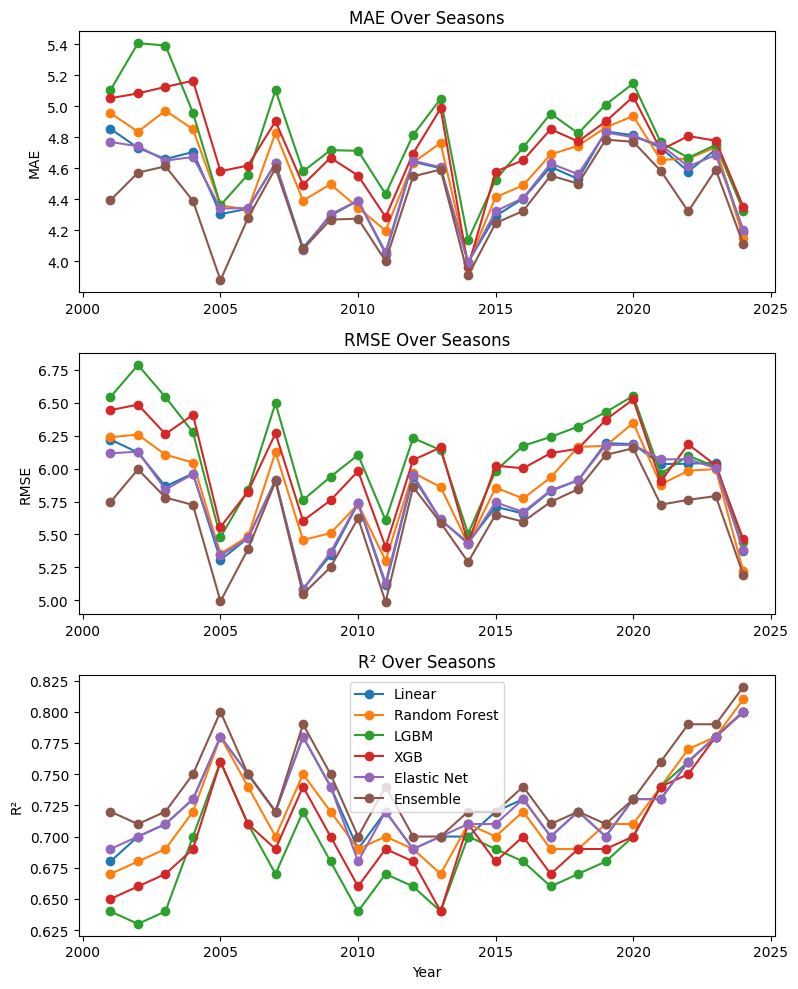

In [204]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# MAE
axes[0].plot(lin_df['Year'], lin_df['MAE'], marker='o', label='Linear')
axes[0].plot(rf_df['Year'], rf_df['MAE'], marker='o', label='Random Forest')
axes[0].plot(rf_df['Year'], lgbm_df['MAE'], marker='o', label='LGBM')
axes[0].plot(rf_df['Year'], xgb_df['MAE'], marker='o', label='XGB')
axes[0].plot(rf_df['Year'], enet_df['MAE'], marker='o', label='Elastic Net')
axes[0].plot(rf_df['Year'], ensemble_df['MAE'], marker='o', label='Ensemble')
axes[0].set_title('MAE Over Seasons')
axes[0].set_ylabel('MAE')

# RMSE
axes[1].plot(lin_df['Year'], lin_df['RMSE'], marker='o', label='Linear')
axes[1].plot(rf_df['Year'], rf_df['RMSE'], marker='o', label='Random Forest')
axes[1].plot(rf_df['Year'], lgbm_df['RMSE'], marker='o', label='LGBM')
axes[1].plot(rf_df['Year'], xgb_df['RMSE'], marker='o', label='XGB')
axes[1].plot(rf_df['Year'], enet_df['RMSE'], marker='o', label='Elastic Net')
axes[1].plot(rf_df['Year'], ensemble_df['RMSE'], marker='o', label='Ensemble')
axes[1].set_title('RMSE Over Seasons')
axes[1].set_ylabel('RMSE')

# R2
axes[2].plot(lin_df['Year'], lin_df['R2'], marker='o', label='Linear')
axes[2].plot(rf_df['Year'], rf_df['R2'], marker='o', label='Random Forest')
axes[2].plot(rf_df['Year'], lgbm_df['R2'], marker='o', label='LGBM')
axes[2].plot(rf_df['Year'], xgb_df['R2'], marker='o', label='XGB')
axes[2].plot(rf_df['Year'], enet_df['R2'], marker='o', label='Elastic Net')
axes[2].plot(rf_df['Year'], ensemble_df['R2'], marker='o', label='Ensemble')
axes[2].set_title('R² Over Seasons')
axes[2].set_ylabel('R²')

plt.legend()

plt.xlabel('Year')
plt.tight_layout()
plt.show()

## Model Performance Comparison

The performance of several models was evaluated across multiple seasons using MAE, RMSE, and R² as metrics. These models included Linear Regression, Random Forest, XGBoost, LightGBM, Elastic Net, a manually weighted ensemble, and a stacked ensemble model.

Overall, the results show that the stacked ensemble model consistently achieved the best performance across all metrics. It produced the lowest MAE and RMSE in most seasons, indicating more accurate predictions, while also achieving the highest R² values, demonstrating superior explanatory power.

Among the individual models, Linear Regression and Elastic Net performed surprisingly well, particularly in terms of error metrics. This suggests that a large portion of the relationship between current season statistics and next season fantasy points per game can be captured through relatively stable linear trends.

The Random Forest model performed competitively, particularly in terms of R², indicating that nonlinear relationships and feature interactions do contribute to predictive performance. However, it was generally slightly outperformed by the linear models in MAE and RMSE.

The gradient boosting models (XGBoost and LightGBM) did not outperform the simpler models in this setting. This may indicate that the underlying signal in the data is not highly complex, or that further hyperparameter tuning would be required to fully leverage these models.

The manually weighted ensemble model improved performance over individual models, demonstrating that combining different model types can capture complementary aspects of the data. However, the stacked ensemble model further improved upon this by learning optimal combinations of model predictions, rather than relying on fixed weights.

# Making Predictions for the Following Season

Now that we have a model, what we aim to do is decide who you should pick in your team for the following season based on the previous season. We will use continue to use the same framework implemented previously with `pulp`.

In [193]:
PREDICTED_TEAMS = {}

for year in range(2001, 2025):
    PRED_FPPG_NEXT = models[year]['ensemble']
    DF_YEAR = df_model[df_model['Year'] == year].copy()
    DF_YEAR['PRED_FPPG_NEXT'] = PRED_FPPG_NEXT

    PREDICTED_TEAMS[year] = {
        'no_position_requirements': optimise_team_salary(DF_YEAR[DF_YEAR['Year'] == year], NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == year]['Salary Cap'], OBJECTIVE_VALUE='PRED_FPPG_NEXT'),
        'position_requirements': optimise_team_salary(DF_YEAR[DF_YEAR['Year'] == year], NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == year]['Salary Cap'], OBJECTIVE_VALUE='PRED_FPPG_NEXT', INCLUDE_POSITION_CONSTRAINT=True)
    }
    


## Summary Plots

In [164]:
summary_rows = []

for year in PREDICTED_TEAMS.keys():
    
    for constraint_type in [
        'no_position_requirements',
        'position_requirements'
    ]:
        
        predicted_team = PREDICTED_TEAMS[year][constraint_type]
        optimised_team = OPTIMISED_TEAMS[year][constraint_type]
        
        summary_rows.append({
            'Season': year,
            'Constraint': constraint_type,
            'Team': 'Predicted',
            'Total_FPPG': predicted_team['FPPG'].sum()
        })
        
        summary_rows.append({
            'Season': year,
            'Constraint': constraint_type,
            'Team': 'Optimal',
            'Total_FPPG': optimised_team['FPPG'].sum()
        })

summary_df = pd.DataFrame(summary_rows)

In [165]:
summary_df['Constraint'] = (
    summary_df['Constraint']
    .str.replace('_', ' ')
    .str.title()
)

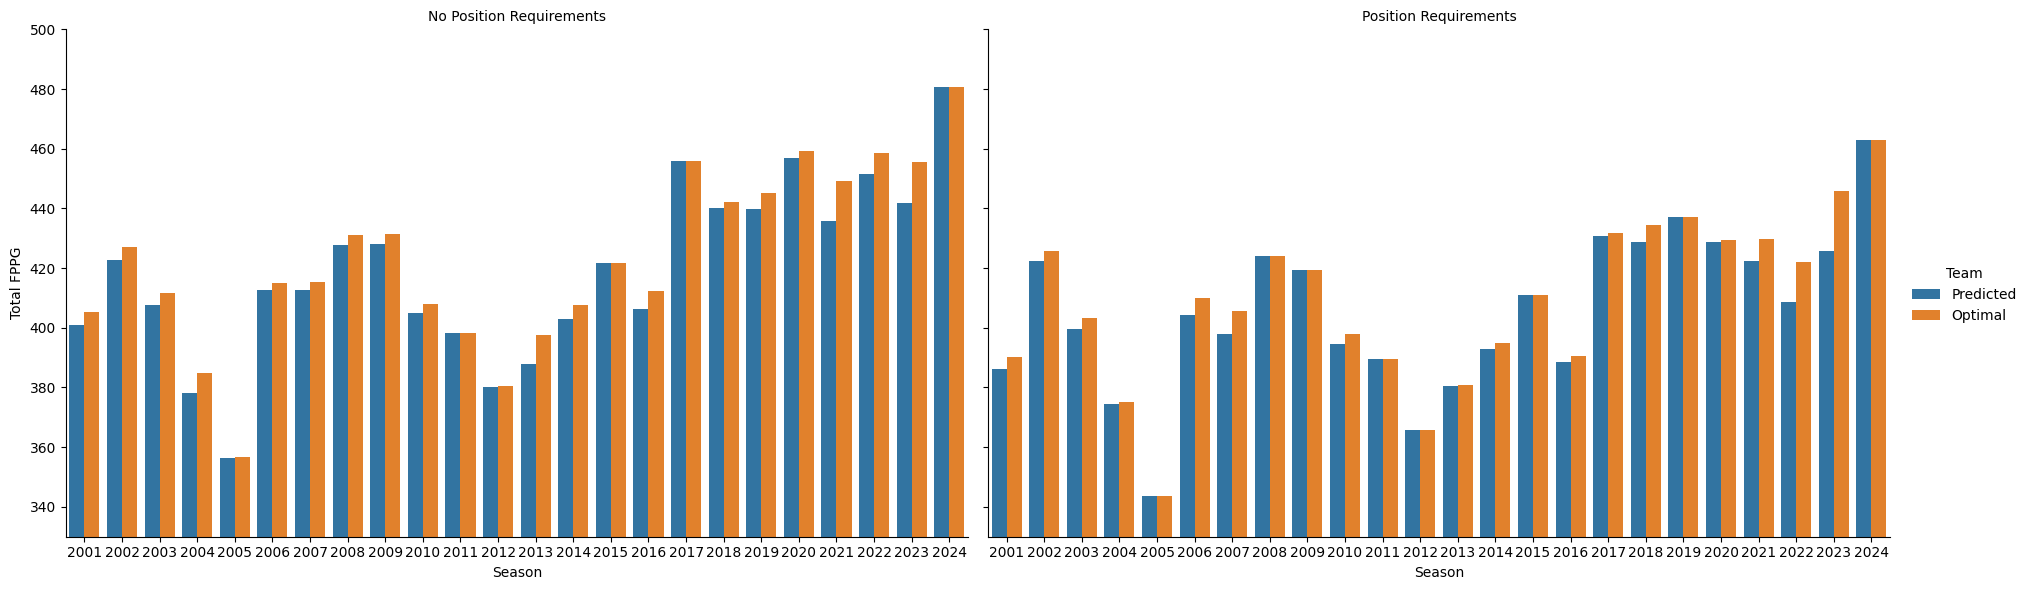

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=summary_df,
    x='Season',
    y='Total_FPPG',
    hue='Team',
    col='Constraint',
    kind='bar',
    height=6,
    aspect=1.6
)

g.set_titles("{col_name}")
g.set_axis_labels("Season", "Total FPPG")


min_value = 330
max_value = 500
plt.ylim(min_value, max_value)

plt.show()

## Summary Tables of Predicted Optimal Team vs Acutal Optimal Team

In [161]:
from IPython.display import display_html

def display_team_comparison(year, constraint_type, salary_cap):
    
    predicted_team = (
        PREDICTED_TEAMS[year][constraint_type]
        .sort_values('Player')
        .reset_index(drop=True)
    )
    
    optimised_team = (
        OPTIMISED_TEAMS[year][constraint_type]
        .sort_values('Player')
        .reset_index(drop=True)
    )
    
    predicted_actual_fppg = predicted_team['FPPG'].sum()
    optimised_actual_fppg = optimised_team['FPPG'].sum()
    
    predicted_salary = predicted_team['Salary'].sum()
    optimised_salary = optimised_team['Salary'].sum()
    
    matching_players = predicted_team['Player'].isin(
        optimised_team['Player']
    ).sum()

    percentage_of_optimal = (
        predicted_actual_fppg / optimised_actual_fppg
    ) * 100
    
    team_size = len(predicted_team)
    
    summary_html = f"""
    <h2>{year} Season — {constraint_type.replace('_', ' ').title()}</h2>
    
    <table style="border-collapse: collapse; margin-bottom: 15px;">
        <tr>
            <th style="border: 1px solid black; padding: 6px;">Metric</th>
            <th style="border: 1px solid black; padding: 6px;">Predicted Team</th>
            <th style="border: 1px solid black; padding: 6px;">Actual Optimal Team</th>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 6px;">Total FPPG</td>
            <td style="border: 1px solid black; padding: 6px;">{predicted_actual_fppg:.2f}</td>
            <td style="border: 1px solid black; padding: 6px;">{optimised_actual_fppg:.2f}</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 6px;">Total Salary</td>
            <td style="border: 1px solid black; padding: 6px;">{predicted_salary:,.0f}</td>
            <td style="border: 1px solid black; padding: 6px;">{optimised_salary:,.0f}</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 6px;">Salary Cap</td>
            <td style="border: 1px solid black; padding: 6px;" colspan="2">{salary_cap:,.0f}</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 6px;">
                % of Optimal Points
            </td>
            <td style="border: 1px solid black; padding: 6px;" colspan="2">
                {percentage_of_optimal:.2f}%
            </td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 6px;">Matching Players</td>
            <td style="border: 1px solid black; padding: 6px;" colspan="2">{matching_players}/{team_size}</td>
        </tr>
    </table>
    """
    
    pred_display = (
        predicted_team[['Player', 'Pos', 'FPPG', 'Salary', 'PRED_FPPG_NEXT']]
        .round(2)
    )

    pred_display = pred_display.rename(columns={'PRED_FPPG_NEXT': 'Predicted FPPG'})
    
    opt_display = (
        optimised_team[['Player', 'Pos', 'FPPG', 'Salary']]
        .round(2)
    )
    
    tables_html = f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        <div>
            <h3>Predicted Optimised Team</h3>
            {pred_display.to_html(index=False)}
        </div>
        <div>
            <h3>Actual Optimal Team</h3>
            {opt_display.to_html(index=False)}
        </div>
    </div>
    """
    
    combined_html = f"""
        <div style="display:flex; gap:40px; align-items:flex-start;">

            <div>
                {summary_html}
            </div>

            <div style="display:flex; gap:30px; align-items:flex-start;">
            
                <div>
                    <h3>Predicted Optimised Team</h3>
                    {pred_display.to_html(index=False)}
                </div>
                
                <div>
                    <h3>Actual Optimal Team</h3>
                    {opt_display.to_html(index=False)}
                </div>
                
            </div>

        </div>
        """

    display_html(combined_html, raw=True)

In [163]:
for year in PREDICTED_TEAMS.keys():
    for constraint_type in ['no_position_requirements', 'position_requirements']:
        display_team_comparison(
            year=year,
            constraint_type=constraint_type,
            salary_cap=NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == 2017]['Salary Cap'].iloc[0]
        )

2001 Season — No Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 401.00 
 405.20 
 
 
 Total Salary 
 35,456,000 
 35,036,000 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 98.96%
 
 
 
 Matching Players 
 7/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Baron Davis 
 PG 
 35.8 
 2916000 
 37.00 
 
 
 Dirk Nowitzki 
 PF 
 40.1 
 1693000 
 38.43 
 
 
 Jason Kidd 
 PG 
 43.1 
 7630000 
 39.34 
 
 
 Mike Bibby 
 PG 
 35.4 
 3308000 
 39.06 
 
 
 Paul Pierce 
 SF 
 39.3 
 1608000 
 37.11 
 
 
 Peja Stojakovic 
 SF 
 32.8 
 1310000 
 34.52 
 
 
 Shawn Marion 
 SF 
 40.3 
 1662000 
 37.19 
 
 
 Steve Francis 
 PG 
 41.3 
 3246000 
 40.37 
 
 
 Tracy McGrady 
 SG 
 47.1 
 9658000 
 44.19 
 
 
 Vince Carter 
 SF 
 45.8 
 2425000 
 42.42 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Andre Miller 
 PG 
 35.1 
 1808000 
 
 
 Antawn Jamison 
 SF 
 36.1 
 2678000 
 
 
 Dirk Nowitzki 
 PF 
 40.1 
 1693000 
 
 
 Jason Kidd 
 PG 
 43.1 
 7630000 
 
 
 Lamar Odom 
 PF 
 37.0 
 2628000 
 
 
 Paul Pierce 
 SF 
 39.3 
 1608000 
 
 
 Shawn Marion 
 SF 
 40.3 
 1662000 
 
 
 Steve Francis 
 PG 
 41.3 
 3246000 
 
 
 Tracy McGrady 
 SG 
 47.1 
 9658000 
 
 
 Vince Carter 
 SF 
 45.8 
 2425000

2001 Season — Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 386.10 
 390.20 
 
 
 Total Salary 
 34,919,000 
 35,090,000 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 98.95%
 
 
 
 Matching Players 
 7/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Dirk Nowitzki 
 PF 
 40.1 
 1693000 
 38.43 
 
 
 Jason Terry 
 SG 
 31.3 
 1579000 
 33.80 
 
 
 Lamar Odom 
 PF 
 37.0 
 2628000 
 36.03 
 
 
 Marcus Camby 
 C 
 35.1 
 5750000 
 29.64 
 
 
 Mike Bibby 
 PG 
 35.4 
 3308000 
 39.06 
 
 
 Raef LaFrentz 
 C 
 32.7 
 2970000 
 29.38 
 
 
 Shawn Marion 
 SF 
 40.3 
 1662000 
 37.19 
 
 
 Steve Francis 
 PG 
 41.3 
 3246000 
 40.37 
 
 
 Tracy McGrady 
 SG 
 47.1 
 9658000 
 44.19 
 
 
 Vince Carter 
 SF 
 45.8 
 2425000 
 42.42 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Andre Miller 
 PG 
 35.1 
 1808000 
 
 
 Ben Wallace 
 C 
 31.9 
 4000000 
 
 
 Dirk Nowitzki 
 PF 
 40.1 
 1693000 
 
 
 Jerry Stackhouse 
 SG 
 38.9 
 5000000 
 
 
 Lamar Odom 
 PF 
 37.0 
 2628000 
 
 
 Raef LaFrentz 
 C 
 32.7 
 2970000 
 
 
 Shawn Marion 
 SF 
 40.3 
 1662000 
 
 
 Steve Francis 
 PG 
 41.3 
 3246000 
 
 
 Tracy McGrady 
 SG 
 47.1 
 9658000 
 
 
 Vince Carter 
 SF 
 45.8 
 2425000

2002 Season — No Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 422.60 
 427.10 
 
 
 Total Salary 
 41,004,000 
 42,031,000 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 98.95%
 
 
 
 Matching Players 
 9/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Andre Miller 
 PG 
 43.2 
 1934000 
 42.04 
 
 
 Baron Davis 
 PG 
 41.8 
 3119000 
 41.73 
 
 
 Dirk Nowitzki 
 C 
 42.7 
 2157000 
 41.58 
 
 
 Jason Terry 
 SG 
 36.8 
 1689000 
 35.05 
 
 
 Paul Pierce 
 SG 
 44.0 
 2051000 
 40.20 
 
 
 Shawn Marion 
 SF 
 40.2 
 1778000 
 38.02 
 
 
 Steve Francis 
 PG 
 36.6 
 3473000 
 35.18 
 
 
 Tim Duncan 
 PF 
 50.6 
 10865000 
 48.02 
 
 
 Tracy McGrady 
 SG 
 47.0 
 10865000 
 47.27 
 
 
 Vince Carter 
 SG 
 39.7 
 3073000 
 37.57 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Andre Miller 
 PG 
 43.2 
 1934000 
 
 
 Baron Davis 
 PG 
 41.8 
 3119000 
 
 
 Ben Wallace 
 C 
 41.1 
 4500000 
 
 
 Dirk Nowitzki 
 C 
 42.7 
 2157000 
 
 
 Jason Terry 
 SG 
 36.8 
 1689000 
 
 
 Paul Pierce 
 SG 
 44.0 
 2051000 
 
 
 Shawn Marion 
 SF 
 40.2 
 1778000 
 
 
 Tim Duncan 
 PF 
 50.6 
 10865000 
 
 
 Tracy McGrady 
 SG 
 47.0 
 10865000 
 
 
 Vince Carter 
 SG 
 39.7 
 3073000

2002 Season — Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 422.30 
 425.70 
 
 
 Total Salary 
 41,239,000 
 41,843,000 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 99.20%
 
 
 
 Matching Players 
 8/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Andre Miller 
 PG 
 43.2 
 1934000 
 42.04 
 
 
 Baron Davis 
 PG 
 41.8 
 3119000 
 41.73 
 
 
 Ben Wallace 
 C 
 41.1 
 4500000 
 35.09 
 
 
 Dirk Nowitzki 
 C 
 42.7 
 2157000 
 41.58 
 
 
 Michael Jordan 
 SF 
 36.1 
 1000000 
 29.84 
 
 
 Pau Gasol 
 PF 
 35.6 
 2970000 
 33.92 
 
 
 Paul Pierce 
 SG 
 44.0 
 2051000 
 40.20 
 
 
 Shawn Marion 
 SF 
 40.2 
 1778000 
 38.02 
 
 
 Tim Duncan 
 PF 
 50.6 
 10865000 
 48.02 
 
 
 Tracy McGrady 
 SG 
 47.0 
 10865000 
 47.27 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Andre Miller 
 PG 
 43.2 
 1934000 
 
 
 Baron Davis 
 PG 
 41.8 
 3119000 
 
 
 Ben Wallace 
 C 
 41.1 
 4500000 
 
 
 Chris Webber 
 PF 
 49.2 
 12750000 
 
 
 Dirk Nowitzki 
 C 
 42.7 
 2157000 
 
 
 Jason Terry 
 SG 
 36.8 
 1689000 
 
 
 Michael Jordan 
 SF 
 36.1 
 1000000 
 
 
 Paul Pierce 
 SG 
 44.0 
 2051000 
 
 
 Shawn Marion 
 SF 
 40.2 
 1778000 
 
 
 Tim Duncan 
 PF 
 50.6 
 10865000

2003 Season — No Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 407.70 
 411.70 
 
 
 Total Salary 
 39,913,000 
 39,976,000 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 99.03%
 
 
 
 Matching Players 
 8/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Dirk Nowitzki 
 PF 
 46.4 
 2923000 
 41.81 
 
 
 Elton Brand 
 PF 
 42.3 
 4895000 
 38.18 
 
 
 Gilbert Arenas 
 PG 
 33.5 
 512000 
 33.80 
 
 
 Jason Terry 
 PG 
 35.9 
 2153000 
 33.18 
 
 
 Jermaine O'Neal 
 PF 
 41.0 
 6950000 
 38.20 
 
 
 Pau Gasol 
 PF 
 35.4 
 3194000 
 33.41 
 
 
 Paul Pierce 
 SG 
 41.4 
 2793000 
 38.63 
 
 
 Ricky Davis 
 SG 
 33.9 
 2156000 
 33.25 
 
 
 Shawn Marion 
 SF 
 45.2 
 2265000 
 39.20 
 
 
 Tracy McGrady 
 SG 
 52.7 
 12072000 
 50.61 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Dirk Nowitzki 
 PF 
 46.4 
 2923000 
 
 
 Elton Brand 
 PF 
 42.3 
 4895000 
 
 
 Gilbert Arenas 
 PG 
 33.5 
 512000 
 
 
 Jason Terry 
 PG 
 35.9 
 2153000 
 
 
 Jermaine O'Neal 
 PF 
 41.0 
 6950000 
 
 
 Michael Jordan 
 SF 
 34.9 
 1030000 
 
 
 Paul Pierce 
 SG 
 41.4 
 2793000 
 
 
 Shawn Marion 
 SF 
 45.2 
 2265000 
 
 
 Steve Francis 
 PG 
 38.4 
 4383000 
 
 
 Tracy McGrady 
 SG 
 52.7 
 12072000

...

2022 Season — Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 408.80 
 422.10 
 
 
 Total Salary 
 108,964,138 
 109,716,719 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 96.85%
 
 
 
 Matching Players 
 6/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Desmond Bane 
 SF 
 33.1 
 2351039 
 34.66 
 
 
 Domantas Sabonis 
 C 
 41.7 
 21392429 
 42.39 
 
 
 Ja Morant 
 PG 
 45.6 
 11104821 
 48.89 
 
 
 Keldon Johnson 
 SF 
 29.4 
 2481198 
 29.85 
 
 
 Luka Doncic 
 PG 
 52.5 
 11765131 
 54.85 
 
 
 Miles Bridges 
 PF 
 38.6 
 6269130 
 38.57 
 
 
 Nikola Jokic 
 C 
 61.7 
 35898700 
 59.65 
 
 
 Scottie Barnes 
 PF 
 33.2 
 8418672 
 34.95 
 
 
 Tyler Herro 
 SG 
 32.2 
 4630339 
 33.31 
 
 
 Tyrese Haliburton 
 SG 
 40.8 
 4652679 
 41.68 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 DeMar DeRozan 
 PF 
 42.8 
 30065035 
 
 
 Desmond Bane 
 SF 
 33.1 
 2351039 
 
 
 Jaylen Hoard 
 SF 
 35.6 
 221856 
 
 
 Luka Doncic 
 PG 
 52.5 
 11765131 
 
 
 Miles Bridges 
 PF 
 38.6 
 6269130 
 
 
 Nikola Jokic 
 C 
 61.7 
 35898700 
 
 
 Robert Williams 
 C 
 36.4 
 4234516 
 
 
 Trae Young 
 PG 
 48.4 
 9628294 
 
 
 Tyler Herro 
 SG 
 32.2 
 4630339 
 
 
 Tyrese Haliburton 
 SG 
 40.8 
 4652679

2023 Season — No Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 441.90 
 455.40 
 
 
 Total Salary 
 122,110,713 
 123,344,706 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 97.04%
 
 
 
 Matching Players 
 6/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Alperen Sengun 
 C 
 33.9 
 3578853 
 36.84 
 
 
 Anthony Edwards 
 SG 
 41.5 
 11380495 
 42.08 
 
 
 Desmond Bane 
 SG 
 38.4 
 2258667 
 39.00 
 
 
 Domantas Sabonis 
 C 
 47.1 
 22372076 
 44.33 
 
 
 Ja Morant 
 PG 
 45.3 
 12850096 
 47.25 
 
 
 Josh Giddey 
 SG 
 36.1 
 6666454 
 38.30 
 
 
 LaMelo Ball 
 PG 
 45.5 
 9143838 
 46.62 
 
 
 Nikola Jokic 
 C 
 60.4 
 35040189 
 56.94 
 
 
 Tyrese Haliburton 
 PG 
 50.4 
 4469241 
 49.51 
 
 
 Zion Williamson 
 PF 
 43.3 
 14350804 
 43.24 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Darius Garland 
 PG 
 39.8 
 9458610 
 
 
 Desmond Bane 
 SG 
 38.4 
 2258667 
 
 
 Ja Morant 
 PG 
 45.3 
 12850096 
 
 
 Joel Embiid 
 C 
 56.9 
 35643458 
 
 
 LaMelo Ball 
 PG 
 45.5 
 9143838 
 
 
 Nikola Jokic 
 C 
 60.4 
 35040189 
 
 
 RaiQuan Gray 
 PF 
 37.0 
 6201 
 
 
 Skylar Mays 
 SG 
 38.4 
 123602 
 
 
 Tyrese Haliburton 
 PG 
 50.4 
 4469241 
 
 
 Zion Williamson 
 PF 
 43.3 
 14350804

2023 Season — Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 425.60 
 445.70 
 
 
 Total Salary 
 122,085,526 
 118,830,328 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 95.49%
 
 
 
 Matching Players 
 5/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Alperen Sengun 
 C 
 33.9 
 3578853 
 36.84 
 
 
 Anthony Edwards 
 SG 
 41.5 
 11380495 
 42.08 
 
 
 Desmond Bane 
 SG 
 38.4 
 2258667 
 39.00 
 
 
 Franz Wagner 
 SF 
 30.9 
 5575291 
 32.74 
 
 
 Jayson Tatum 
 PF 
 50.0 
 32181628 
 50.24 
 
 
 Keldon Johnson 
 SF 
 31.3 
 4106520 
 31.31 
 
 
 LaMelo Ball 
 PG 
 45.5 
 9143838 
 46.62 
 
 
 Nikola Jokic 
 C 
 60.4 
 35040189 
 56.94 
 
 
 Tyrese Haliburton 
 PG 
 50.4 
 4469241 
 49.51 
 
 
 Zion Williamson 
 PF 
 43.3 
 14350804 
 43.24 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Desmond Bane 
 SG 
 38.4 
 2258667 
 
 
 Joel Embiid 
 C 
 56.9 
 35643458 
 
 
 LaMelo Ball 
 PG 
 45.5 
 9143838 
 
 
 Lauri Markkanen 
 SF 
 41.4 
 17468726 
 
 
 Louis King 
 SF 
 34.0 
 325602 
 
 
 Nikola Jokic 
 C 
 60.4 
 35040189 
 
 
 RaiQuan Gray 
 PF 
 37.0 
 6201 
 
 
 Skylar Mays 
 SG 
 38.4 
 123602 
 
 
 Tyrese Haliburton 
 PG 
 50.4 
 4469241 
 
 
 Zion Williamson 
 PF 
 43.3 
 14350804

2024 Season — No Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 480.80 
 480.80 
 
 
 Total Salary 
 134,828,039 
 134,828,039 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 100.00%
 
 
 
 Matching Players 
 10/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Alperen Sengun 
 C 
 42.8 
 3641356 
 41.31 
 
 
 Desmond Bane 
 SG 
 41.2 
 3959335 
 40.67 
 
 
 Evan Mobley 
 PF 
 38.4 
 9146578 
 37.51 
 
 
 LaMelo Ball 
 PG 
 45.4 
 11224536 
 45.60 
 
 
 Luka Doncic 
 PG 
 63.9 
 41254687 
 58.95 
 
 
 Scottie Barnes 
 SG 
 46.0 
 8246649 
 46.34 
 
 
 Shai Gilgeous-Alexander 
 PG 
 56.8 
 34378905 
 54.94 
 
 
 Tyrese Haliburton 
 PG 
 50.3 
 5981026 
 49.93 
 
 
 Tyrese Maxey 
 PG 
 44.8 
 4472995 
 42.93 
 
 
 Victor Wembanyama 
 C 
 51.2 
 12521972 
 50.53 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Alperen Sengun 
 C 
 42.8 
 3641356 
 
 
 Desmond Bane 
 SG 
 41.2 
 3959335 
 
 
 Evan Mobley 
 PF 
 38.4 
 9146578 
 
 
 LaMelo Ball 
 PG 
 45.4 
 11224536 
 
 
 Luka Doncic 
 PG 
 63.9 
 41254687 
 
 
 Scottie Barnes 
 SG 
 46.0 
 8246649 
 
 
 Shai Gilgeous-Alexander 
 PG 
 56.8 
 34378905 
 
 
 Tyrese Haliburton 
 PG 
 50.3 
 5981026 
 
 
 Tyrese Maxey 
 PG 
 44.8 
 4472995 
 
 
 Victor Wembanyama 
 C 
 51.2 
 12521972

2024 Season — Position Requirements 
 
 
 
 Metric 
 Predicted Team 
 Actual Optimal Team 
 
 
 Total FPPG 
 463.00 
 463.00 
 
 
 Total Salary 
 135,980,082 
 135,980,082 
 
 
 Salary Cap 
 94,143,000 
 
 
 
 % of Optimal Points
 
 
 100.00%
 
 
 
 Matching Players 
 10/10 
 
 
 
 

 
 
 
 Predicted Optimised Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 Predicted FPPG 
 
 
 
 
 Alperen Sengun 
 C 
 42.8 
 3641356 
 41.31 
 
 
 Desmond Bane 
 SG 
 41.2 
 3959335 
 40.67 
 
 
 Franz Wagner 
 SF 
 34.7 
 5672405 
 35.83 
 
 
 Giannis Antetokounmpo 
 PF 
 58.3 
 46996232 
 56.01 
 
 
 Jalen Johnson 
 SF 
 37.2 
 3012284 
 35.66 
 
 
 Jalen Williams 
 PF 
 37.4 
 4694136 
 36.87 
 
 
 Luka Doncic 
 PG 
 63.9 
 41254687 
 58.95 
 
 
 Scottie Barnes 
 SG 
 46.0 
 8246649 
 46.34 
 
 
 Tyrese Haliburton 
 PG 
 50.3 
 5981026 
 49.93 
 
 
 Victor Wembanyama 
 C 
 51.2 
 12521972 
 50.53 
 
 
 
 
 
 
 Actual Optimal Team 
 
 
 
 Player 
 Pos 
 FPPG 
 Salary 
 
 
 
 
 Alperen Sengun 
 C 
 42.8 
 3641356 
 
 
 Desmond Bane 
 SG 
 41.2 
 3959335 
 
 
 Franz Wagner 
 SF 
 34.7 
 5672405 
 
 
 Giannis Antetokounmpo 
 PF 
 58.3 
 46996232 
 
 
 Jalen Johnson 
 SF 
 37.2 
 3012284 
 
 
 Jalen Williams 
 PF 
 37.4 
 4694136 
 
 
 Luka Doncic 
 PG 
 63.9 
 41254687 
 
 
 Scottie Barnes 
 SG 
 46.0 
 8246649 
 
 
 Tyrese Haliburton 
 PG 
 50.3 
 5981026 
 
 
 Victor Wembanyama 
 C 
 51.2 
 12521972